In [3]:
import pandas as pd
import numpy as np

print("--- INIZIO FASE 1: PRE-PROCESSING E MATCHING STRATIFICATO ---")

df = pd.read_excel('Tabella.xlsx')

df['Target_Malato'] = df['Gruppo'].apply(lambda x: 1 if 'malato' in str(x).lower() else 0)

df['Altezza_m'] = df['Altezza_in'] * 0.0254
df['BMI'] = df['Peso_kg'] / (df['Altezza_m'] ** 2)
df = df.drop(columns=['Gruppo', 'Altezza_in', 'Peso_kg', 'Altezza_m'])

df = pd.get_dummies(df, columns=['Sesso', 'Race'], drop_first=True)

malati = df[df['Target_Malato'] == 1].copy()
sani = df[df['Target_Malato'] == 0].copy()

sani_selezionati = []
sani_disponibili = sani.copy()

for _, malato in malati.iterrows():
    sani_stesso_sesso = sani_disponibili[sani_disponibili['Sesso_Male'] == malato['Sesso_Male']]
    
    if not sani_stesso_sesso.empty:
        distanze = (sani_stesso_sesso['Eta'] - malato['Eta']).abs()
        indice_migliore = distanze.idxmin()
        
        sani_selezionati.append(sani_stesso_sesso.loc[indice_migliore])
        sani_disponibili = sani_disponibili.drop(indice_migliore)

sani_matched = pd.DataFrame(sani_selezionati)

df_matched = pd.concat([malati, sani_matched]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nDimensioni campione ORIGINALE: {len(df)} soggetti")
print(f"Dimensioni campione BILANCIATO: {len(df_matched)} soggetti (Età e Sesso normalizzati)")

colonne_etnia = [col for col in df_matched.columns if 'Race' in col]
colonne_finali = ['ID_Soggetto', 'Target_Malato', 'Eta', 'BMI', 'Sesso_Male'] + colonne_etnia

df_finale = df_matched[colonne_finali]
df_finale.to_excel('Dataset_Parkinson_Processato_Matched.xlsx', index=False)

print("Tabella esportata con successo: 'Dataset_Parkinson_Processato_Matched.xlsx'.")

--- INIZIO FASE 1: PRE-PROCESSING E MATCHING STRATIFICATO ---

Dimensioni campione ORIGINALE: 173 soggetti
Dimensioni campione BILANCIATO: 164 soggetti (Età e Sesso normalizzati)


PermissionError: [Errno 13] Permission denied: 'Dataset_Parkinson_Processato_Matched.xlsx'

<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:82: SyntaxWarning: invalid escape sequence '\D'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:82: SyntaxWarning: invalid escape sequence '\D'
C:\Users\marta\AppData\Local\Temp\ipykernel_10948\3277989927.py:76: SyntaxWarning: invalid escape sequence '\D'
  axes[0, 0].set_title(f"Paradosso nutrizionale: indice di massa corporea\n(p-value Welch: {p_val_bmi:.4e} | Glass's $\Delta$: {delta_bmi:.2f})", fontweight='bold')
C:\Users\marta\AppData\Local\Temp\ipykernel_10948\3277989927.py:82: SyntaxWarning: invalid escape sequence '\D'
  axes[0, 1].set_title(f"Bias anagrafico residuo: età\n(p-value Welch: {p_val_eta:.4e} | Glass's $\Delta$: {delta_eta:.2f})", fontweight='bold')


--- INIZIO FASE 2: ANALISI BIVARIATA SUL CAMPIONE BILANCIATO ---

[VARIABILE CONTINUA: ETÀ - Verifica Post-Matching]
Media Sani (Controllo): 72.46 anni | Media Malati: 68.63 anni
P-value (Welch): 5.5087e-04 (Significativo!)
Glass's Delta: 0.46

[VARIABILE CONTINUA: BMI]
Media Sani (Controllo): 28.48 | Media Malati: 25.76
P-value (Welch): 7.7709e-04 (Significativo!)
Glass's Delta (Effect Size): 0.52

[VARIABILE CATEGORICA: SESSO (0=F, 1=M)]
Distribuzione Percentuale (riga):
Sesso_Male     False  True 
Target_Malato              
0              47.1%  52.9%
1              35.1%  64.9%
P-value Chi-Quadro (Correzione di Yates): 1.6340e-01 (Non significativo)

[VARIABILE CATEGORICA MULTIPLA: ETNIA RICOSTRUITA (Variabile di Controllo)]
Distribuzione Percentuale (riga):
Etnia_Ricostruita Etnia_Baseline Race_Asian Race_Black  \
Target_Malato                                            
0                           1.4%       1.4%      11.4%   
1                           0.0%       5.3%       0.

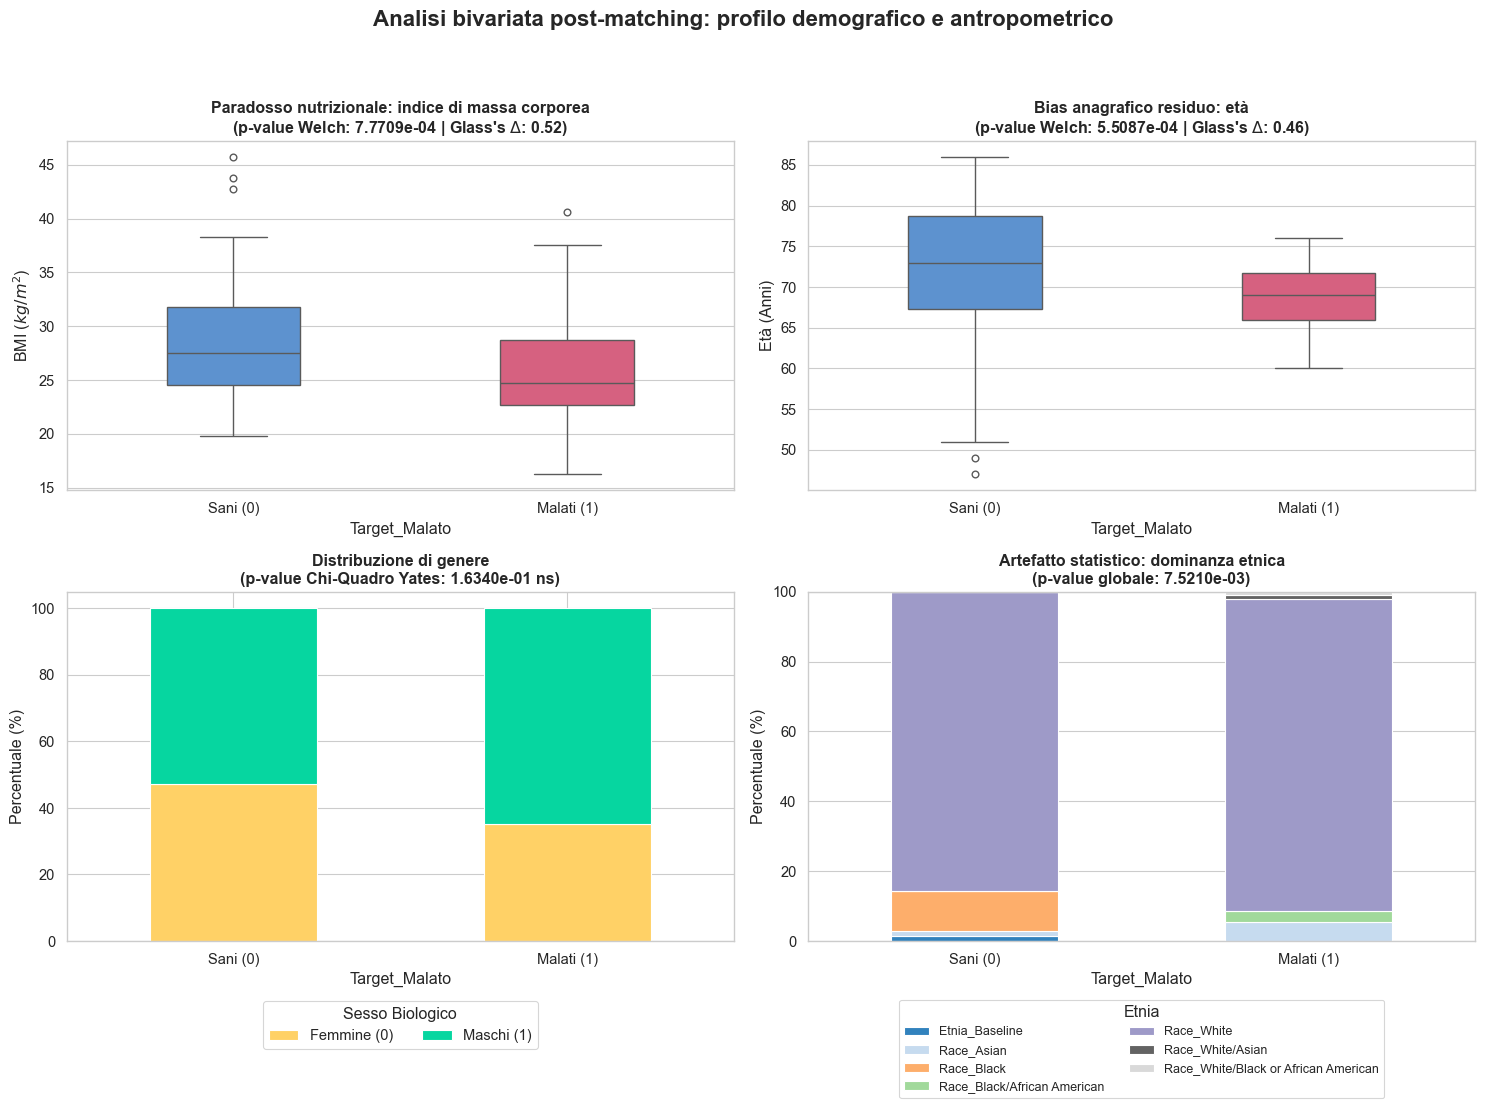

Pre-processing completato: variabile 'Etnia_Ricostruita' rimossa per prevenire multicollinearità.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def calcola_glass_delta(control_group, treatment_group):
    std_control = control_group.std(ddof=1)
    diff_medie = treatment_group.mean() - control_group.mean()
    return abs(diff_medie / std_control) if std_control != 0 else np.nan

df = pd.read_excel('Dataset_Parkinson_Processato_Matched.xlsx')

print("--- INIZIO FASE 2: ANALISI BIVARIATA SUL CAMPIONE BILANCIATO ---\n")

sani = df[df['Target_Malato'] == 0]
malati = df[df['Target_Malato'] == 1]

eta_sani, eta_malati = sani['Eta'].dropna(), malati['Eta'].dropna()
t_stat_eta, p_val_eta = stats.ttest_ind(eta_sani, eta_malati, equal_var=False)
delta_eta = calcola_glass_delta(eta_sani, eta_malati)

print("[VARIABILE CONTINUA: ETÀ - Verifica Post-Matching]")
print(f"Media Sani (Controllo): {eta_sani.mean():.2f} anni | Media Malati: {eta_malati.mean():.2f} anni")
print(f"P-value (Welch): {p_val_eta:.4e} " + ("(Significativo!)" if p_val_eta < 0.05 else "(Non significativo, Matching Riuscito!)"))
print(f"Glass's Delta: {delta_eta:.2f}\n")

bmi_sani, bmi_malati = sani['BMI'].dropna(), malati['BMI'].dropna()
t_stat_bmi, p_val_bmi = stats.ttest_ind(bmi_sani, bmi_malati, equal_var=False)
delta_bmi = calcola_glass_delta(bmi_sani, bmi_malati)

print("[VARIABILE CONTINUA: BMI]")
print(f"Media Sani (Controllo): {bmi_sani.mean():.2f} | Media Malati: {bmi_malati.mean():.2f}")
print(f"P-value (Welch): {p_val_bmi:.4e} " + ("(Significativo!)" if p_val_bmi < 0.05 else "(Non significativo)"))
print(f"Glass's Delta (Effect Size): {delta_bmi:.2f}\n")

if 'Sesso_Male' in df.columns:
    tabella_sesso = pd.crosstab(df['Target_Malato'], df['Sesso_Male'])
    tabella_sesso_pct = pd.crosstab(df['Target_Malato'], df['Sesso_Male'], normalize='index') * 100
    
    chi2_s, p_val_sesso, dof_s, expected_s = stats.chi2_contingency(tabella_sesso, correction=True)

    print("[VARIABILE CATEGORICA: SESSO (0=F, 1=M)]")
    print("Distribuzione Percentuale (riga):")
    print(tabella_sesso_pct.round(1).astype(str) + '%')
    print(f"P-value Chi-Quadro (Correzione di Yates): {p_val_sesso:.4e} " + ("(Significativo!)" if p_val_sesso < 0.05 else "(Non significativo)\n"))

colonne_etnia = [col for col in df.columns if 'Race' in col]

if colonne_etnia:
    def determina_etnia_originale(row):
        for col in colonne_etnia:
            if row[col] == 1:
                return col
        return 'Etnia_Baseline' 

    df['Etnia_Ricostruita'] = df.apply(determina_etnia_originale, axis=1)
    
    tabella_e = pd.crosstab(df['Target_Malato'], df['Etnia_Ricostruita'])
    tabella_e_pct = pd.crosstab(df['Target_Malato'], df['Etnia_Ricostruita'], normalize='index') * 100
    
    chi2_e, p_val_e, dof_e, expected_e = stats.chi2_contingency(tabella_e, correction=False)
    
    print(f"[VARIABILE CATEGORICA MULTIPLA: ETNIA RICOSTRUITA (Variabile di Controllo)]")
    print("Distribuzione Percentuale (riga):")
    print(tabella_e_pct.round(1).astype(str) + '%')
    print(f"P-value Chi-Quadro Globale: {p_val_e:.4e} " + ("(Significativo!)" if p_val_e < 0.05 else "(Non significativo - Convalida l'esclusione dai predittori attivi)\n"))

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle("Analisi bivariata post-matching: profilo demografico e antropometrico", fontsize=16, fontweight='bold', y=0.98)

colori_target = ["#4A90E2", "#E94E77"]  

sns.boxplot(data=df, x='Target_Malato', y='BMI', hue='Target_Malato', legend=False, ax=axes[0, 0], palette=colori_target, width=0.4)
axes[0, 0].set_title(f"Paradosso nutrizionale: indice di massa corporea\n(p-value Welch: {p_val_bmi:.4e} | Glass's $\Delta$: {delta_bmi:.2f})", fontweight='bold')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Sani (0)', 'Malati (1)'])
axes[0, 0].set_ylabel("BMI ($kg/m^2$)")

sns.boxplot(data=df, x='Target_Malato', y='Eta', hue='Target_Malato', legend=False, ax=axes[0, 1], palette=colori_target, width=0.4)
axes[0, 1].set_title(f"Bias anagrafico residuo: età\n(p-value Welch: {p_val_eta:.4e} | Glass's $\Delta$: {delta_eta:.2f})", fontweight='bold')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Sani (0)', 'Malati (1)'])
axes[0, 1].set_ylabel("Età (Anni)")

if 'Sesso_Male' in df.columns:
    sesso_pct_plot = pd.crosstab(df['Target_Malato'], df['Sesso_Male'], normalize='index') * 100
    sesso_pct_plot.plot(kind='bar', stacked=True, ax=axes[1, 0], color=["#FFD166", "#06D6A0"])
    axes[1, 0].set_title(f"Distribuzione di genere\n(p-value Chi-Quadro Yates: {p_val_sesso:.4e} ns)", fontweight='bold')
    axes[1, 0].set_xticklabels(['Sani (0)', 'Malati (1)'], rotation=0)
    axes[1, 0].set_ylabel("Percentuale (%)")
    axes[1, 0].legend(['Femmine (0)', 'Maschi (1)'], title="Sesso Biologico", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

if 'Etnia_Ricostruita' in df.columns:
    etnia_pct_plot = pd.crosstab(df['Target_Malato'], df['Etnia_Ricostruita'], normalize='index') * 100
    etnia_pct_plot.plot(kind='bar', stacked=True, ax=axes[1, 1], colormap='tab20c')
    axes[1, 1].set_title(f"Artefatto statistico: dominanza etnica\n(p-value globale: {p_val_e:.4e})", fontweight='bold')
    axes[1, 1].set_xticklabels(['Sani (0)', 'Malati (1)'], rotation=0)
    axes[1, 1].set_ylabel("Percentuale (%)")
    axes[1, 1].legend(title="Etnia", loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])
plt.show()

if 'Etnia_Ricostruita' in df.columns:
    df.drop(columns=['Etnia_Ricostruita'], inplace=True)
    print("Pre-processing completato: variabile 'Etnia_Ricostruita' rimossa per prevenire multicollinearità.")

--- INIZIO FASE 3: SPLITTING E STANDARDIZZAZIONE (Z-SCORE) ---
Dimensioni Training Set: 114 pazienti
Dimensioni Test Set: 50 pazienti

--- INIZIO FASE 4: REGRESSIONE LOGISTICA MULTIVARIATA ---

[SUMMARY DEL MODELLO LOGISTICO MULTIVARIATO]
                           Logit Regression Results                           
Dep. Variable:          Target_Malato   No. Observations:                  114
Model:                          Logit   Df Residuals:                      109
Method:                           MLE   Df Model:                            4
Date:                Wed, 24 Jun 2026   Pseudo R-squ.:                  0.1239
Time:                        12:53:16   Log-Likelihood:                -68.239
converged:                       True   LL-Null:                       -77.892
Covariance Type:            nonrobust   LLR p-value:                 0.0006840
                            coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------

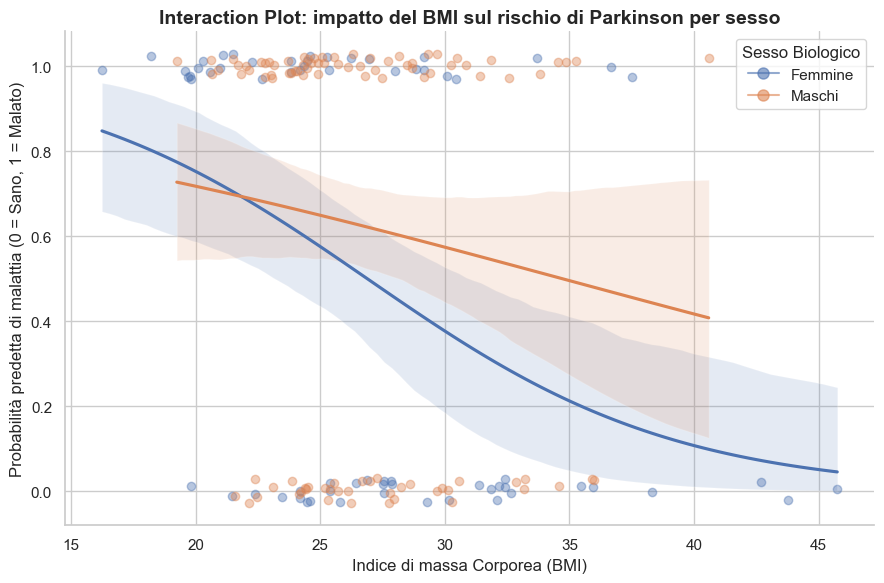

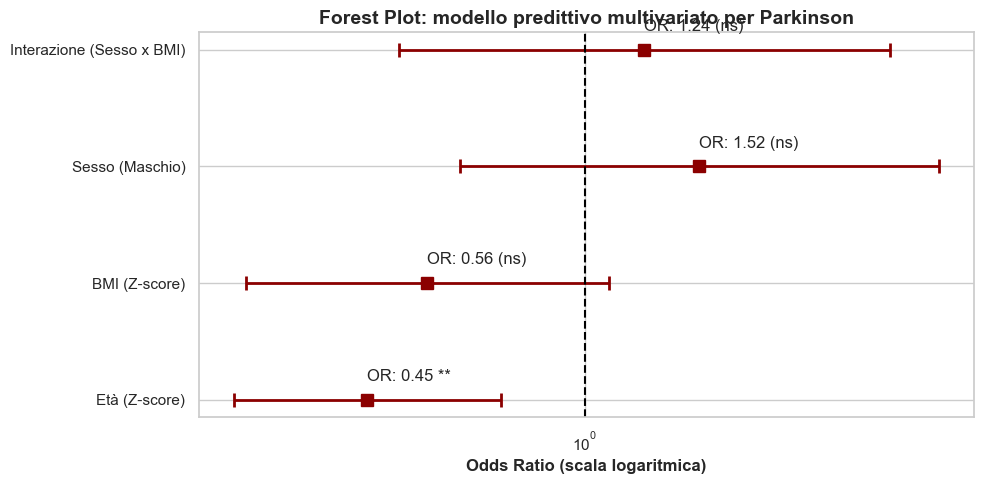

In [5]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("--- INIZIO FASE 3: SPLITTING E STANDARDIZZAZIONE (Z-SCORE) ---")

df = pd.read_excel('Dataset_Parkinson_Processato_Matched.xlsx')

X = df[['Eta', 'BMI', 'Sesso_Male']]
y = df['Target_Malato']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Dimensioni Training Set: {len(X_train)} pazienti")
print(f"Dimensioni Test Set: {len(X_test)} pazienti\n")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

colonne_continue = ['Eta', 'BMI']
X_train_scaled[colonne_continue] = scaler.fit_transform(X_train[colonne_continue])
X_test_scaled[colonne_continue] = scaler.transform(X_test[colonne_continue])

X_train_scaled['Interazione_Sesso_BMI'] = X_train_scaled['Sesso_Male'] * X_train_scaled['BMI']

X_train_scaled = sm.add_constant(X_train_scaled)

print("--- INIZIO FASE 4: REGRESSIONE LOGISTICA MULTIVARIATA ---")

X_train_scaled = X_train_scaled.astype(float)
y_train = y_train.astype(float)

modello_logit = sm.Logit(y_train, X_train_scaled).fit(disp=False)

print("\n[SUMMARY DEL MODELLO LOGISTICO MULTIVARIATO]")
print(modello_logit.summary())

df_risultati = pd.DataFrame({
    'Odds Ratio': np.exp(modello_logit.params),
    'CI 2.5%': np.exp(modello_logit.conf_int()[0]),
    'CI 97.5%': np.exp(modello_logit.conf_int()[1]),
    'P-value': modello_logit.pvalues
})

print("\n--- ODDS RATIO E INTERVALLI DI CONFIDENZA (AL 95%) ---")
print(df_risultati.round(4))

sns.set_theme(style="whitegrid")

g = sns.lmplot(x="BMI", y="Target_Malato", hue="Sesso_Male", data=df, 
               logistic=True, y_jitter=.03, scatter_kws={'alpha':0.4}, 
               legend=False, height=6, aspect=1.5, palette=['#4C72B0', '#DD8452'])

plt.title("Interaction Plot: impatto del BMI sul rischio di Parkinson per sesso", fontsize=14, weight='bold')
plt.xlabel("Indice di massa Corporea (BMI)", fontsize=12)
plt.ylabel("Probabilità predetta di malattia (0 = Sano, 1 = Malato)", fontsize=12)

femmine_marker = mlines.Line2D([], [], color='#4C72B0', marker='o', linestyle='-',
                               markersize=8, alpha=0.6, label='Femmine')
maschi_marker = mlines.Line2D([], [], color='#DD8452', marker='o', linestyle='-',
                              markersize=8, alpha=0.6, label='Maschi')

plt.legend(handles=[femmine_marker, maschi_marker], title='Sesso Biologico', loc='upper right')

plt.tight_layout()
plt.savefig('Interaction_Plot_BMI_Sesso_Corretto.png', dpi=300, bbox_inches='tight')
print("\nSalvataggio grafico completato: 'Interaction_Plot_BMI_Sesso_Corretto.png'")

plt.figure(figsize=(10, 5))

variabili_plot = df_risultati.drop('const')
y_pos = np.arange(len(variabili_plot))
x_or = variabili_plot['Odds Ratio']
x_err_low = x_or - variabili_plot['CI 2.5%']
x_err_high = variabili_plot['CI 97.5%'] - x_or

plt.errorbar(x_or, y_pos, xerr=[x_err_low, x_err_high], fmt='s', color='darkred', 
             capsize=5, capthick=2, elinewidth=2, markersize=8)

plt.axvline(x=1.0, color='black', linestyle='--', linewidth=1.5)
plt.yticks(y_pos, ['Età (Z-score)', 'BMI (Z-score)', 'Sesso (Maschio)', 'Interazione (Sesso x BMI)'])
plt.xscale('log') 
plt.xlabel("Odds Ratio (scala logaritmica)", fontsize=12, weight='bold')
plt.title("Forest Plot: modello predittivo multivariato per Parkinson", fontsize=14, weight='bold')

for i, (p_val, or_val) in enumerate(zip(variabili_plot['P-value'], x_or)):
    sig_stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else '(ns)'
    plt.text(x_or.iloc[i], i + 0.2, f"OR: {or_val:.2f} {sig_stars}", va='center')

plt.tight_layout()
plt.savefig('Forest_Plot_Multivariato.png', dpi=300, bbox_inches='tight')
print("Salvataggio grafico completato: 'Forest_Plot_Multivariato.png'")
plt.show()

In [6]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# 1. Caricamento del dataset
df = pd.read_excel('Tabella.xlsx')

# Pre-processing di base come fatto nello studio
df['Target_Malato'] = df['Gruppo'].apply(lambda x: 1 if 'malato' in str(x).lower() else 0)
df['Altezza_m'] = df['Altezza_in'] * 0.0254
df['BMI'] = df['Peso_kg'] / (df['Altezza_m'] ** 2)
df = pd.get_dummies(df, columns=['Sesso'], drop_first=True)

# Definiamo i due subset: Malati e Sani
malati = df[df['Target_Malato'] == 1].copy()
sani = df[df['Target_Malato'] == 0].copy()

# =====================================================================
# PILASTRO 1: Correlazione con la Severità Motoria (Stadiazione H&Y sui Malati)
# =====================================================================
print("--- Analisi H&Y sui Malati ---")

# Binarizzazione H&Y
# Drop dei missing values su H&Y per i malati
malati_hy = malati.dropna(subset=['Hoehn_Yahr', 'BMI', 'Eta', 'Sesso_Male']).copy()

# Gruppo "Fase Iniziale/Lieve" (0) vs "Fase Moderata/Avanzata" (1)
malati_hy['HY_Avanzato'] = malati_hy['Hoehn_Yahr'].apply(lambda x: 1 if x >= 3 else 0)

print(f"Pazienti malati con H&Y registrato: {len(malati_hy)}")
print(f"Distribuzione H&Y Avanzato:\n{malati_hy['HY_Avanzato'].value_counts()}")

# T-test sul BMI tra i due gruppi H&Y
bmi_lieve = malati_hy[malati_hy['HY_Avanzato'] == 0]['BMI']
bmi_avanzato = malati_hy[malati_hy['HY_Avanzato'] == 1]['BMI']

t_stat, p_val_ttest = stats.ttest_ind(bmi_lieve, bmi_avanzato, equal_var=False)
print(f"\nT-test BMI: Media Lieve={bmi_lieve.mean():.2f}, Media Avanzato={bmi_avanzato.mean():.2f}, p-value={p_val_ttest:.4f}")

# Regressione Logistica
scaler = StandardScaler()
X_malati = malati_hy[['BMI', 'Eta', 'Sesso_Male']].copy()
X_malati[['BMI', 'Eta']] = scaler.fit_transform(X_malati[['BMI', 'Eta']])
X_malati['Sesso_BMI'] = X_malati['Sesso_Male'] * X_malati['BMI']
X_malati = sm.add_constant(X_malati)
y_malati = malati_hy['HY_Avanzato']

X_malati = X_malati.astype(float)
y_malati = y_malati.astype(float)

try:
    logit_model = sm.Logit(y_malati, X_malati).fit(disp=False)
    print("\nRegressione Logistica (Target: H&Y Avanzato):")
    print(logit_model.summary().tables[1])
except Exception as e:
    print("\nErrore nella regressione logistica:", e)

# =====================================================================
# PILASTRO 2: Il Destino del MoCA (Riserva Cognitiva sui Sani)
# =====================================================================
print("\n--- Analisi MoCA sui Sani ---")

sani_moca = sani.dropna(subset=['MoCA', 'BMI', 'Eta', 'Sesso_Male']).copy()
print(f"Pazienti sani con MoCA registrato: {len(sani_moca)}")

# Regressione Lineare Multipla
X_sani = sani_moca[['BMI', 'Eta', 'Sesso_Male']].copy()
# Non standardizziamo qui per interpretare i coefficienti in unità originali
X_sani['Sesso_BMI'] = X_sani['Sesso_Male'] * X_sani['BMI']
X_sani = sm.add_constant(X_sani)
y_sani = sani_moca['MoCA']

X_sani = X_sani.astype(float)
y_sani = y_sani.astype(float)

ols_model = sm.OLS(y_sani, X_sani).fit()
print("\nRegressione Lineare OLS (Target: MoCA):")
print(ols_model.summary().tables[1])

# Ricerca della soglia: Creiamo gruppi di BMI
sani_moca['BMI_Group'] = pd.cut(sani_moca['BMI'], bins=[0, 25, 30, 100], labels=['Normopeso (<25)', 'Sovrappeso (25-30)', 'Obesi (>30)'])
moca_by_bmi = sani_moca.groupby('BMI_Group', observed=False)['MoCA'].agg(['mean', 'std', 'count'])
print("\nMoCA per gruppi di BMI:")
print(moca_by_bmi)


--- Analisi H&Y sui Malati ---
Pazienti malati con H&Y registrato: 89
Distribuzione H&Y Avanzato:
HY_Avanzato
0    76
1    13
Name: count, dtype: int64

T-test BMI: Media Lieve=25.91, Media Avanzato=23.99, p-value=0.1305

Regressione Logistica (Target: H&Y Avanzato):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.4170      1.185     -2.882      0.004      -5.740      -1.094
BMI           -1.1434      0.921     -1.242      0.214      -2.948       0.661
Eta           -0.4547      0.418     -1.087      0.277      -1.274       0.365
Sesso_Male     1.9786      1.290      1.533      0.125      -0.550       4.508
Sesso_BMI      0.5945      1.030      0.577      0.564      -1.425       2.614

--- Analisi MoCA sui Sani ---
Pazienti sani con MoCA registrato: 42

Regressione Lineare OLS (Target: MoCA):
                 coef    std err          t      P>|t|      [0.025   

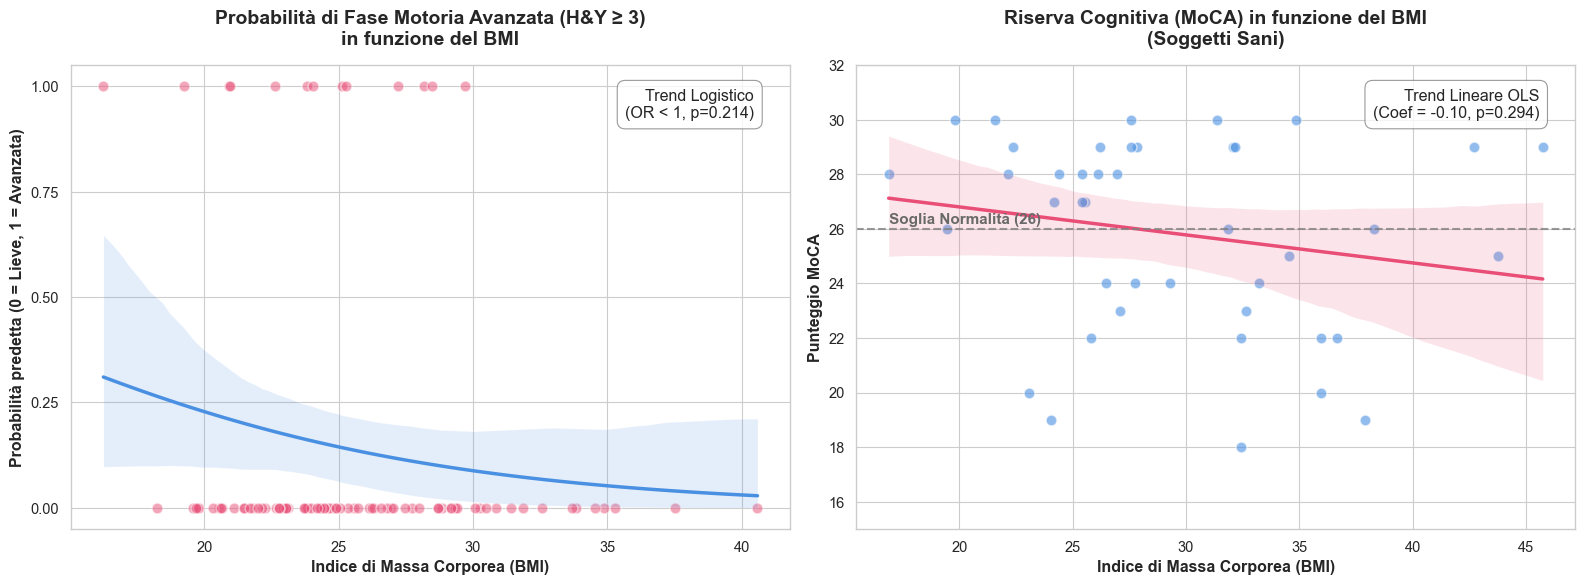

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('Tabella.xlsx')

df['Target_Malato'] = df['Gruppo'].apply(lambda x: 1 if 'malato' in str(x).lower() else 0)
df['Altezza_m'] = df['Altezza_in'] * 0.0254
df['BMI'] = df['Peso_kg'] / (df['Altezza_m'] ** 2)

malati = df[df['Target_Malato'] == 1].copy()
malati_hy = malati.dropna(subset=['Hoehn_Yahr', 'BMI']).copy()
malati_hy['HY_Avanzato'] = malati_hy['Hoehn_Yahr'].apply(lambda x: 1 if x >= 3 else 0)

sani = df[df['Target_Malato'] == 0].copy()
sani_moca = sani.dropna(subset=['MoCA', 'BMI']).copy()

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(data=malati_hy, x='BMI', y='HY_Avanzato', logistic=True, ci=95,
            scatter_kws={'alpha': 0.5, 'color': '#E94E77', 's': 60, 'edgecolor': 'white'},
            line_kws={'color': '#4A90E2', 'linewidth': 2.5}, ax=axes[0])

axes[0].set_title('Probabilità di Fase Motoria Avanzata (H&Y ≥ 3)\nin funzione del BMI', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Probabilità predetta (0 = Lieve, 1 = Avanzata)', fontweight='bold')
axes[0].set_xlabel('Indice di Massa Corporea (BMI)', fontweight='bold')
axes[0].set_yticks([0, 0.25, 0.5, 0.75, 1])
axes[0].text(0.95, 0.95, 'Trend Logistico\n(OR < 1, p=0.214)', 
             ha='right', va='top', transform=axes[0].transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

sns.regplot(data=sani_moca, x='BMI', y='MoCA', ci=95,
            scatter_kws={'alpha': 0.6, 'color': '#4A90E2', 's': 60, 'edgecolor': 'white'},
            line_kws={'color': '#E94E77', 'linewidth': 2.5}, ax=axes[1])

axes[1].set_title('Riserva Cognitiva (MoCA) in funzione del BMI\n(Soggetti Sani)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Punteggio MoCA', fontweight='bold')
axes[1].set_xlabel('Indice di Massa Corporea (BMI)', fontweight='bold')
axes[1].set_ylim(15, 32)

axes[1].axhline(26, color='gray', linestyle='--', linewidth=1.5, alpha=0.8)
axes[1].text(min(sani_moca['BMI']), 26.2, 'Soglia Normalità (26)', color='dimgray', fontsize=11, fontweight='bold')
axes[1].text(0.95, 0.95, 'Trend Lineare OLS\n(Coef = -0.10, p=0.294)', 
             ha='right', va='top', transform=axes[1].transAxes, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.savefig('Analisi_Regressione_Continua.png', dpi=300, bbox_inches='tight')
plt.show()